# Single fit PCA-HMM (No test-train)

In [1]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

from statsmodels.tsa.stattools import acf 
from statsmodels.graphics.tsaplots import plot_acf 
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler  

from hmmlearn import hmm

In [2]:
seed = 123 
random.seed(seed)

In [41]:
tickers = ["XLK","XLV","XLF","XLY","XLC","XLI","XLP","XLE","XLU","XLRE","XLB","^VIX", "^SPX"]

sector_data = yf.download(tickers, start="2019-01-01", end='2026-03-29', auto_adjust = False)["Adj Close"]

sector_data.head()

[*********************100%***********************]  13 of 13 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
Date,,,,,,,,,,,,,
2019-01-02,22.028011,39.142059,21.261770,21.041233,57.592117,29.068300,41.901951,23.986853,20.903227,75.582718,46.748024,2510.030029,23.219999
2019-01-03,21.403353,38.487049,21.050894,20.568193,55.839630,27.601292,41.661224,24.097715,20.899212,74.047989,45.735832,2447.889893,25.450001
2019-01-04,22.244904,40.143311,21.767132,21.251471,57.956856,28.824579,42.549404,24.343206,21.208675,76.256943,47.249424,2531.939941,21.379999
2019-01-07,22.322985,40.601818,22.090712,21.277750,58.428329,29.082357,42.491295,24.549101,21.063992,76.549690,48.317844,2549.689941,21.400000
2019-01-08,22.557236,41.284908,22.261591,21.295265,59.228977,29.326080,42.881424,24.976730,21.325228,77.144073,48.852055,2574.409912,20.469999


Quickly can check/prove the non-stationarity of the time series with an ACF plot

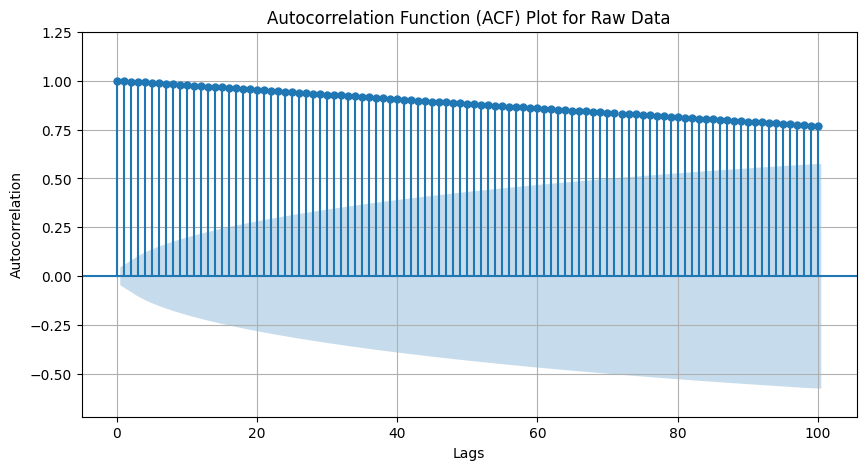

In [42]:
plt.figure(figsize=(10, 5))
plot_acf(sector_data['^SPX'].dropna(), ax=plt.gca(), lags=100, auto_ylims=True)
plt.title("Autocorrelation Function (ACF) Plot for Raw Data")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

In [43]:
returns = sector_data.pct_change().dropna()
returns.head(10)

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
Date,,,,,,,,,,,,,
2019-01-03,-0.028357,-0.016734,-0.009918,-0.022482,-0.030429,-0.050468,-0.005745,0.004622,-0.000192,-0.020305,-0.021652,-0.024757,0.096038
2019-01-04,0.039319,0.043034,0.034024,0.033220,0.037916,0.044320,0.021319,0.010187,0.014807,0.029831,0.033094,0.034336,-0.159921
2019-01-07,0.003510,0.011422,0.014866,0.001237,0.008135,0.008943,-0.001366,0.008458,-0.006822,0.003839,0.022612,0.007010,0.000935
2019-01-08,0.010494,0.016824,0.007735,0.000823,0.013703,0.008380,0.009181,0.017419,0.012402,0.007765,0.011056,0.009695,-0.043458
2019-01-09,0.000385,0.001360,0.015842,0.004936,0.006759,0.012946,-0.009291,-0.004122,-0.006031,0.004485,0.005084,0.004098,-0.023937
2019-01-10,0.008843,0.002037,0.002894,0.000410,0.013576,0.004418,0.005861,0.015918,0.013083,0.001946,-0.002863,0.004518,-0.024024
2019-01-11,-0.004001,-0.004970,-0.005931,0.002455,-0.001030,-0.001885,0.002914,0.001880,-0.003743,0.003314,0.000957,-0.000146,-0.067179
2019-01-14,-0.007653,-0.003632,-0.002419,0.006939,-0.000148,-0.009286,-0.004842,-0.003128,-0.022544,-0.011046,-0.006120,-0.005258,0.048378
2019-01-15,-0.006555,0.016632,0.003557,0.008917,-0.003095,0.015091,0.009926,0.011296,0.012300,0.017964,0.009044,0.010722,-0.024646


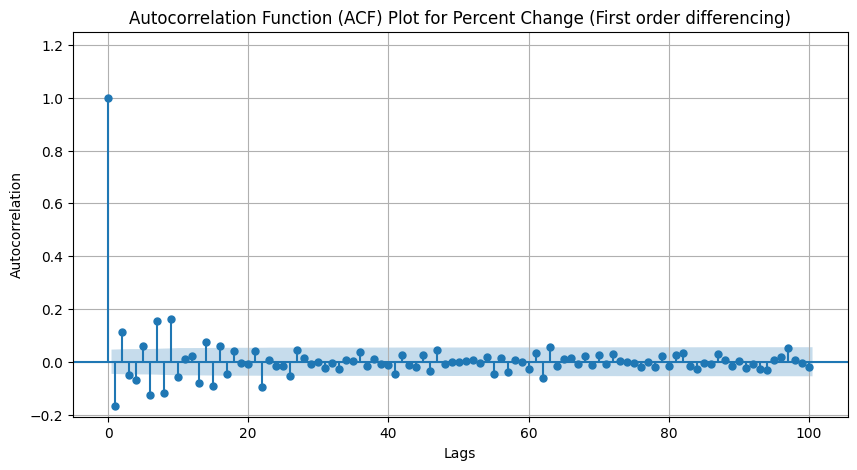

In [44]:
plt.figure(figsize=(10, 5))
plot_acf(returns['^SPX'], ax=plt.gca(), lags=100, auto_ylims=True)
plt.title("Autocorrelation Function (ACF) Plot for Percent Change (First order differencing)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

In [45]:
sector_corr = returns.corr()

Text(0.5, 1.0, 'Correlations Matrix for the Sector Returns')

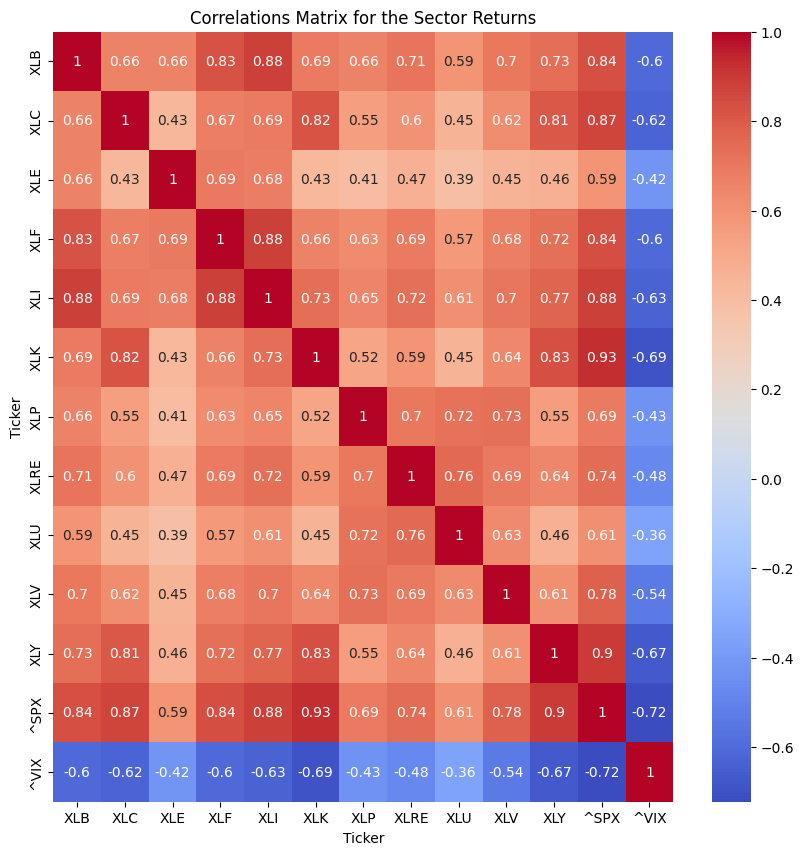

In [46]:
plt.figure(figsize=(10,10))
sns.heatmap(sector_corr, cmap="coolwarm", annot=True)
plt.title("Correlations Matrix for the Sector Returns")

OK so an option is to do training on a given ste of the data building out the hmm model then when we can evaluate the hmm on a test set time series of the data to get the log liklihood on the test set 

Would need to transform the test data using the PCA results of the training data 

In [47]:
scaler = StandardScaler()

returns_scaled = pd.DataFrame(
    scaler.fit_transform(returns), 
    columns = returns.columns 
)
returns_scaled.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
0,-2.054480,-1.235053,-0.521961,-1.527399,-2.288065,-3.068890,-0.621579,0.300488,-0.053724,-1.883933,-1.453023,-2.036732,1.107084
1,2.757320,3.010460,1.616596,2.164072,2.743230,2.586968,2.108406,0.694912,1.084578,2.675179,2.127264,2.711627,-1.951297
2,0.211315,0.764940,0.684196,0.044455,0.550862,0.476069,-0.179834,0.572355,-0.556858,0.311593,1.441773,0.515911,-0.029266
3,0.707855,1.148684,0.337188,0.017056,0.960766,0.442502,0.884062,1.207442,0.902034,0.668572,0.686024,0.731651,-0.559710
4,-0.010898,0.050207,0.731716,0.289631,0.449542,0.714901,-0.979276,-0.319157,-0.496816,0.370306,0.295467,0.281887,-0.326465


In [48]:
pca = PCA(random_state=seed)
pca.fit_transform(returns_scaled)

array([[-5.06431495e+00,  1.81634935e+00, -1.23229118e-03, ...,
         5.69309254e-01, -1.20028308e-01,  2.62159259e-01],
       [ 7.93444317e+00, -1.06848985e+00, -6.51504723e-03, ...,
         1.05717767e-02,  3.03760918e-01, -7.60975179e-02],
       [ 1.40164826e+00, -9.64505498e-01,  1.94566629e-01, ...,
         5.26943268e-01,  3.46668125e-01, -5.26130515e-02],
       ...,
       [ 1.48200625e+00, -1.05424342e-01, -2.89554568e-01, ...,
         4.73480432e-01, -1.28139246e-01,  2.91229094e-02],
       [-2.91897427e+00,  1.81270288e+00,  1.19014930e+00, ...,
         5.55688311e-01, -9.29696008e-01, -4.55226673e-02],
       [-3.08836285e+00,  2.09523344e+00,  8.95267167e-01, ...,
        -5.56265604e-01,  7.13461758e-02, -6.25172889e-02]],
      shape=(1818, 13))

[6.84744458e+01 8.63283833e+00 6.43807729e+00 3.26238963e+00
 2.78437035e+00 2.21509439e+00 2.00687655e+00 1.65783104e+00
 1.43599850e+00 1.24427734e+00 1.11508511e+00 7.00650382e-01
 3.20653070e-02]


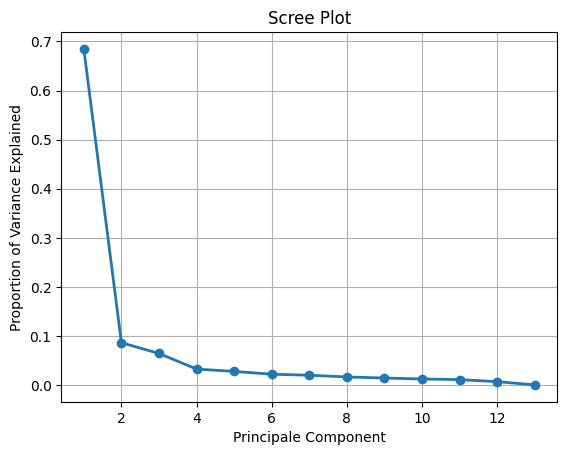

In [49]:
pc_explained_var = pca.explained_variance_ratio_
PC_vals = np.arange(len(pca.explained_variance_ratio_)) + 1

print(pc_explained_var*100)

plt.plot(PC_vals, pc_explained_var, 'o-', linewidth=2)
plt.title("Scree Plot")
plt.xlabel("Principale Component")
plt.ylabel("Proportion of Variance Explained")
plt.grid(True)
plt.show()

From the elbow it looks like taking 3 or 4 PC's might be a good move to capture a significant portion of the variance. This is something that can be tuned

Refit using just 3 PC's

In [50]:
pca = PCA(n_components=3, random_state=seed)

latent_variables = pca.fit_transform(returns_scaled)
latent_variables.shape

(1818, 3)

In [51]:
Saved_PC = ["PC1", 'PC2', "PC3"]
df_loadings = pd.DataFrame(
    pca.components_, 
    columns = returns.columns, 
    index = Saved_PC 
)
df_loadings.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
PC1,0.299890,0.276844,0.219126,0.297175,0.308906,0.283486,0.256055,0.274651,0.235639,0.274648,0.289277,0.326725,-0.242738
PC2,0.045032,-0.289267,0.045027,0.015226,0.008410,-0.341079,0.397634,0.310762,0.526476,0.189880,-0.284882,-0.150817,0.351868
PC3,0.225211,-0.225858,0.744654,0.293516,0.224102,-0.222252,-0.217067,-0.133249,-0.185825,-0.180081,-0.132039,-0.074750,0.055976


In PC1 -> Vix lower and S&P increased


In PC2/3 -> Vix higher and S&P lower 

In [52]:
hmm_model = hmm.GaussianHMM(n_components=2, random_state=seed)
hmm_model.fit(latent_variables)

,n_components,2
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,123


In [53]:
probs = pd.Series(hmm_model.predict(latent_variables), index = returns.index)

# Number of days that we are each in regime
probs.value_counts()

1    1489
0     329
Name: count, dtype: int64

In [54]:
# Transition matrix -> Likely hood of transitioning between states 
transition_matrix = hmm_model.transmat_
transition_matrix

array([[0.76962878, 0.23037122],
       [0.06006211, 0.93993789]])

In [55]:
#State Means
df_means = pd.DataFrame(
    hmm_model.means_,
    columns = Saved_PC,
)
df_means

,PC1,PC2,PC3
0,-0.540702,0.174337,0.084673
1,0.141505,-0.045625,-0.022160


So this result shows the PC1 contributes positively to the first regime (Low Vix and High SPY) which likely indicates this is the bullish region. 

Next we can look at the regime classification using the outputs of the HMM on the actual time series data 

Text(0, 0.5, 'Daily % Returns')

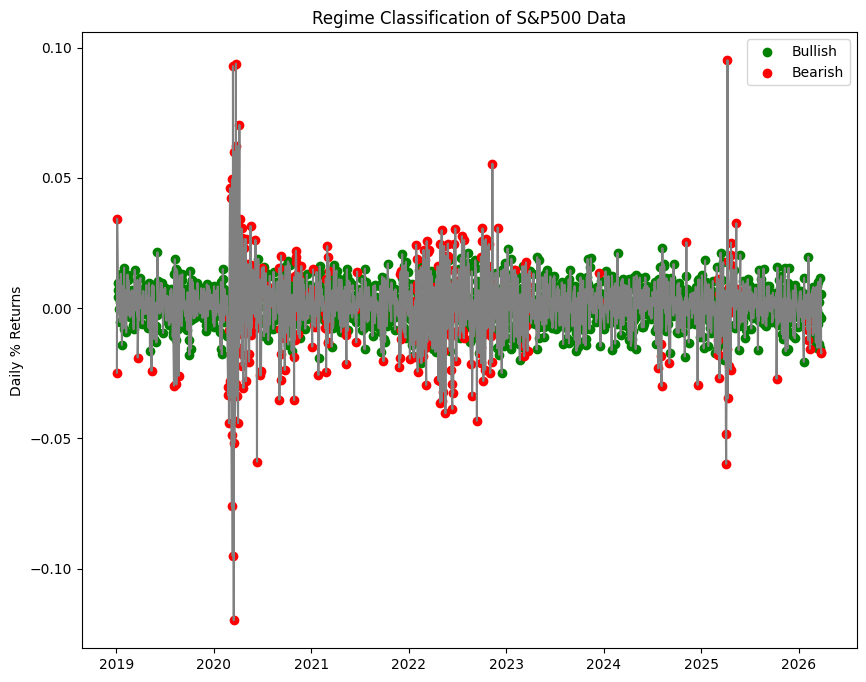

In [56]:
plt.figure(figsize=(10,8))
plt.plot(returns['^SPX'], color='gray')
plt.scatter(returns.index[probs == 1], returns['^SPX'][probs == 1], color='green', label = 'Bullish')
plt.scatter(returns.index[probs == 0], returns['^SPX'][probs == 0], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data")
plt.legend()
plt.ylabel("Daily % Returns")


In [57]:
#Build the 3 month returns data
spy_3m_return = ((1 + returns['^SPX']).rolling(60).apply(np.prod, raw= True) - 1).dropna()
spy_3m_return

Date
2019-03-29    0.129229
2019-04-01    0.171290
2019-04-02    0.132428
2019-04-03    0.126961
2019-04-04    0.118466
                ...   
2026-03-23   -0.047583
2026-03-24   -0.054195
2026-03-25   -0.048780
2026-03-26   -0.062061
2026-03-27   -0.076475
Name: ^SPX, Length: 1759, dtype: float64

In [58]:
matched_prediction = probs[len(returns) - len(spy_3m_return):]

Text(0, 0.5, '3M Returns (%)')

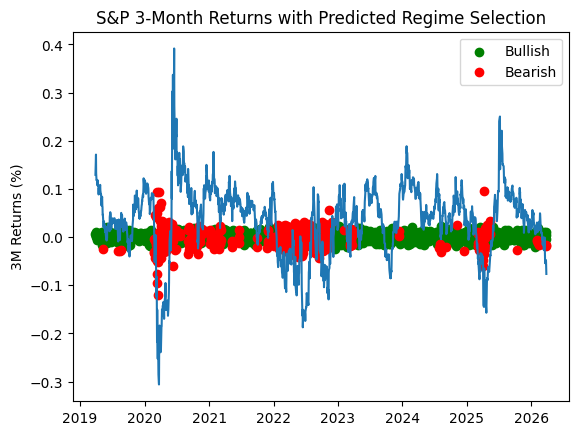

In [59]:
plt.plot(spy_3m_return)
plt.scatter(returns.index[len(returns) - len(spy_3m_return):][matched_prediction == 1], returns['^SPX'][len(returns) - len(spy_3m_return):][matched_prediction  == 1], color='green', label = 'Bullish')
plt.scatter(returns.index[len(returns) - len(spy_3m_return):][matched_prediction  == 0], returns['^SPX'][len(returns) - len(spy_3m_return):][matched_prediction == 0], color='red', label = 'Bearish')
plt.legend()
plt.title("S&P 3-Month Returns with Predicted Regime Selection")
plt.ylabel("3M Returns (%)")